In [1]:
!pip -q install stratify metpy

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

In [3]:
overpass_path = Path.home() / "my-public-bucket" / "orcestra" / "overpass"
overpass_files = sorted(list(overpass_path.glob("*.nc")))

In [4]:
dt = xr.open_datatree(overpass_files[0])

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
dt.noaa_20

<xarray.DataTree 'noaa_20'>
Group: /noaa_20
    Dimensions:                    (atrack: 15, xtrack: 10, utc_tuple: 8,
                                    fov_poly: 8, spatial: 3, attitude: 3,
                                    air_pres_stand: 27, air_pres_h2o_stand: 11)
    Coordinates:
        lat                        (atrack, xtrack) float32 600B ...
        lon                        (atrack, xtrack) float32 600B ...
        subsat_lat                 (atrack) float32 60B ...
        subsat_lon                 (atrack) float32 60B ...
        attitude_lbl               (attitude) <U5 60B ...
        spatial_lbl                (spatial) <U1 12B ...
        utc_tuple_lbl              (utc_tuple) <U11 352B ...
      * air_pres_stand             (air_pres_stand) float32 108B 1e+05 ... 10.0
      * air_pres_h2o_stand         (air_pres_h2o_stand) float32 44B 1e+05 ... 1.5...
    Dimensions without coordinates: atrack, xtrack, utc_tuple, fov_poly, spatial,
                                    attitude
    Data variables: (12/83)
        obs_id                     (atrack, xtrack) <U20 12kB ...
        obs_time_tai93             (atrack, xtrack) datetime64[ns] 1kB ...
        obs_time_utc               (atrack, xtrack, utc_tuple) float32 5kB ...
        lat_geoid                  (atrack, xtrack) float32 600B ...
        lon_geoid                  (atrack, xtrack) float32 600B ...
        lat_bnds                   (atrack, xtrack, fov_poly) float32 5kB ...
        ...                         ...
        tpause_pres                (atrack, xtrack) float32 600B ...
        tpause_pres_qc             (atrack, xtrack) float32 600B ...
        tpause_temp                (atrack, xtrack) float32 600B ...
        tpause_temp_qc             (atrack, xtrack) float32 600B ...
        air_pres_stand_nsurf       (atrack, xtrack) float32 600B ...
        mw_surf_class              (atrack, xtrack) float32 600B ...
    Attributes: (12/82)
        geospatial_bounds:                 POLYGON ((86.04 14.29, 62.86 17.77, 58...
        product_name_version:              v03_21
        product_name_extension:            nc
        geospatial_lon_min:                58.613804
        creator_institution:               Goddard Space Flight Center - National...
        id:                                10.5067/69Y2R9BJAJS3
        ...                                ...
        AutomaticQualityFlag:              Passed
        instrument_vocabulary:             GCMD:GCMD Keywords
        date_created:                      2024-09-24T20:18:07.000Z
        license:                           Freely Distributed
        algorithm_version:                 V3.0.0,(20-Jan-2022)firo:1.0(30-JAN-2019)
        cdm_data_type:                     Swath

In [6]:
new_ds = dt.noaa_20.to_dataset()[[]].copy()
new_ds = new_ds.assign_coords(
    lat=dt.noaa_20.lat,
    lon=dt.noaa_20.lon,
    height=xr.DataArray(
        np.arange(50, 2e4, 100), dims="height", attrs=dict(units="m")
    ),
    obs_time_tai93=dt.noaa_20.obs_time_tai93
)

In [7]:
new_ds

<xarray.Dataset> Size: 4kB
Dimensions:         (atrack: 15, xtrack: 10, height: 200)
Coordinates:
    lat             (atrack, xtrack) float32 600B ...
    lon             (atrack, xtrack) float32 600B ...
    subsat_lat      (atrack) float32 60B 13.99 13.84 13.68 ... 12.11 11.96 11.8
    subsat_lon      (atrack) float32 60B 74.06 74.02 73.98 ... 73.62 73.59 73.55
  * height          (height) float64 2kB 50.0 150.0 ... 1.985e+04 1.995e+04
    obs_time_tai93  (atrack, xtrack) datetime64[ns] 1kB ...
Dimensions without coordinates: atrack, xtrack
Data variables:
    *empty*
Attributes: (12/82)
    geospatial_bounds:                 POLYGON ((86.04 14.29, 62.86 17.77, 58...
    product_name_version:              v03_21
    product_name_extension:            nc
    geospatial_lon_min:                58.613804
    creator_institution:               Goddard Space Flight Center - National...
    id:                                10.5067/69Y2R9BJAJS3
    ...                                ...
    AutomaticQualityFlag:              Passed
    instrument_vocabulary:             GCMD:GCMD Keywords
    date_created:                      2024-09-24T20:18:07.000Z
    license:                           Freely Distributed
    algorithm_version:                 V3.0.0,(20-Jan-2022)firo:1.0(30-JAN-2019)
    cdm_data_type:                     Swath

In [8]:
def interp_sounder_full(ds, variable, old_height, new_height, args):
    if f'surf_{variable}' in ds.data_vars:
        missing_dim = [dim for dim in ds[variable].dims if dim not in ds[f'surf_{variable}'].dims][0]
        return stratify.interpolate(
            new_height,
            old_height,
            np.take_along_axis(
                xr.concat(
                    [
                        ds[f'surf_{variable}'].expand_dims(missing_dim, axis=-1).assign_coords({missing_dim:[1.1e5]}), 
                        ds[variable], 
                    ], 
                    missing_dim
                ).values, 
                args,
                axis=-1
            ),
            axis=-1,
            rising=True
        )

    old_height = ds.gp_hgt.sel(air_pres_stand=ds.air_pres_h2o_stand).fillna(-np.inf).values \
        if "air_pres_h2o_stand" in ds[variable].dims \
        else ds.gp_hgt.fillna(-np.inf).values

    return stratify.interpolate(
        new_height,
        old_height,
        ds[variable].values,
        axis=-1,
        rising=True
    )

In [9]:
# Interp T
import stratify

def regrid_sounder_dataset(ds):
    new_ds = ds.to_dataset()[[]].copy()
    new_ds = new_ds.assign_coords(
        lat=ds.lat,
        lon=ds.lon,
        height=xr.DataArray(
            np.arange(50, 2e4, 100), dims="height", attrs=dict(units="m")
        ),
        obs_time_tai93=ds.obs_time_tai93
    )
    gp_height_full = xr.concat(
        [
            ds.surf_gp_hgt.expand_dims("air_pres_stand", axis=-1).assign_coords(air_pres_stand=[1e5]), 
            ds.gp_hgt, 
        ], 
        "air_pres_stand"
    )
    args = gp_height_full.argsort(-1)
    height_full = np.take_along_axis(gp_height_full.values, args, axis=-1)
    height_full[~np.isfinite(height_full)] = -np.inf
    
    gp_height_h2o = xr.concat(
        [
            ds.surf_gp_hgt.expand_dims("air_pres_h2o_stand", axis=-1).assign_coords(air_pres_h2o_stand=[1e5]), 
            ds.gp_hgt.sel(air_pres_stand=ds.air_pres_h2o_stand).drop_vars("air_pres_stand"), 
        ], 
        "air_pres_h2o_stand"
    )
    args_h2o = gp_height_h2o.argsort(-1)
    height_h20 = np.take_along_axis(gp_height_h2o.values, args_h2o, axis=-1)
    height_h20[~np.isfinite(height_h20)] = -np.inf
    
    for variable in [
        "air_temp",
        "surf_air_temp",
        "h2o_vap_tot",
        "spec_hum",
        "surf_spec_hum",
        "rel_hum",
        "surf_rel_hum",
        "h2o_liq_tot",
        "h2o_liq_mmr",
        "h2o_ice_tot",
        "h2o_ice_mmr",
        "surf_temp",
        "tpause_gp_hgt",
        "tpause_pres",
        "tpause_temp",
    ]:
        if "air_pres_stand" in ds[variable].dims:
            new_ds[variable] = xr.DataArray(
                interp_sounder_full(
                    ds, variable, height_full, new_ds.height.values, args
                ),
                dims=("atrack", "xtrack", "height"),
                attrs=ds[variable].attrs,
            )
    
            if f'{variable}_qc' in ds:
                new_ds[f'{variable}_qc'] = xr.DataArray(
                    np.ceil(interp_sounder_full(
                        ds, f'{variable}_qc', height_full, new_ds.height.values, args
                    )),
                    dims=("atrack", "xtrack", "height"),
                    attrs=ds[f'{variable}_qc'].attrs,
                )
    
            if f'{variable}_err' in ds:
                new_ds[f'{variable}_err'] = xr.DataArray(
                    interp_sounder_full(
                        ds, f'{variable}_err', height_full, new_ds.height.values, args
                    ),
                    dims=("atrack", "xtrack", "height"),
                    attrs=ds[f'{variable}_err'].attrs,
                )
    
        elif "air_pres_h2o_stand" in ds[variable].dims:
            new_ds[variable] = xr.DataArray(
                interp_sounder_full(
                    ds, variable, height_h20, new_ds.height.values, args_h2o
                ),
                dims=("atrack", "xtrack", "height"),
                attrs=ds[variable].attrs,
            )
    
            if f'{variable}_qc' in ds:
                new_ds[f'{variable}_qc'] = xr.DataArray(
                    np.ceil(interp_sounder_full(
                        ds, f'{variable}_qc', height_h20, new_ds.height.values, args_h2o
                    )),
                    dims=("atrack", "xtrack", "height"),
                    attrs=ds[f'{variable}_qc'].attrs,
                )
    
            if f'{variable}_err' in ds:
                new_ds[f'{variable}_err'] = xr.DataArray(
                    interp_sounder_full(
                        ds, f'{variable}_err', height_h20, new_ds.height.values, args_h2o
                    ),
                    dims=("atrack", "xtrack", "height"),
                    attrs=ds[f'{variable}_err'].attrs,
                )
    
        else:
            new_ds[variable] = ds[variable]
            if f'{variable}_qc' in ds:
                new_ds[f'{variable}_qc'] = ds[f'{variable}_qc']
            if f'{variable}_err' in ds:
                new_ds[f'{variable}_err'] = ds[f'{variable}_err']

    return new_ds

In [10]:
new_n20_ds = regrid_sounder_dataset(dt.noaa_20)

In [11]:
new_n20_ds

<xarray.Dataset> Size: 2MB
Dimensions:            (atrack: 15, xtrack: 10, height: 200)
Coordinates:
    lat                (atrack, xtrack) float32 600B ...
    lon                (atrack, xtrack) float32 600B ...
    subsat_lat         (atrack) float32 60B 13.99 13.84 13.68 ... 11.96 11.8
    subsat_lon         (atrack) float32 60B 74.06 74.02 73.98 ... 73.59 73.55
  * height             (height) float64 2kB 50.0 150.0 ... 1.985e+04 1.995e+04
    obs_time_tai93     (atrack, xtrack) datetime64[ns] 1kB ...
Dimensions without coordinates: atrack, xtrack
Data variables: (12/42)
    air_temp           (atrack, xtrack, height) float32 120kB nan nan ... nan
    air_temp_qc        (atrack, xtrack, height) float32 120kB nan nan ... nan
    air_temp_err       (atrack, xtrack, height) float32 120kB nan nan ... nan
    surf_air_temp      (atrack, xtrack) float32 600B nan nan 299.7 ... nan nan
    surf_air_temp_qc   (atrack, xtrack) float32 600B nan nan 2.0 ... 0.0 nan nan
    surf_air_temp_err  (atrack, xtrack) float32 600B nan nan nan ... nan nan nan
    ...                 ...
    tpause_gp_hgt      (atrack, xtrack) float32 600B ...
    tpause_gp_hgt_qc   (atrack, xtrack) float32 600B ...
    tpause_pres        (atrack, xtrack) float32 600B ...
    tpause_pres_qc     (atrack, xtrack) float32 600B ...
    tpause_temp        (atrack, xtrack) float32 600B ...
    tpause_temp_qc     (atrack, xtrack) float32 600B ...
Attributes: (12/82)
    geospatial_bounds:                 POLYGON ((86.04 14.29, 62.86 17.77, 58...
    product_name_version:              v03_21
    product_name_extension:            nc
    geospatial_lon_min:                58.613804
    creator_institution:               Goddard Space Flight Center - National...
    id:                                10.5067/69Y2R9BJAJS3
    ...                                ...
    AutomaticQualityFlag:              Passed
    instrument_vocabulary:             GCMD:GCMD Keywords
    date_created:                      2024-09-24T20:18:07.000Z
    license:                           Freely Distributed
    algorithm_version:                 V3.0.0,(20-Jan-2022)firo:1.0(30-JAN-2019)
    cdm_data_type:                     Swath

In [12]:
new_snpp_ds = regrid_sounder_dataset(dt.snpp)

In [13]:
new_snpp_ds

<xarray.Dataset> Size: 3MB
Dimensions:            (atrack: 14, xtrack: 16, height: 200)
Coordinates:
    lat                (atrack, xtrack) float32 896B ...
    lon                (atrack, xtrack) float32 896B ...
    subsat_lat         (atrack) float32 56B 12.92 12.77 12.61 ... 11.04 10.89
    subsat_lon         (atrack) float32 56B 80.05 80.01 79.98 ... 79.62 79.58
  * height             (height) float64 2kB 50.0 150.0 ... 1.985e+04 1.995e+04
    obs_time_tai93     (atrack, xtrack) datetime64[ns] 2kB ...
Dimensions without coordinates: atrack, xtrack
Data variables: (12/42)
    air_temp           (atrack, xtrack, height) float32 179kB nan nan ... nan
    air_temp_qc        (atrack, xtrack, height) float32 179kB nan nan ... nan
    air_temp_err       (atrack, xtrack, height) float32 179kB nan nan ... nan
    surf_air_temp      (atrack, xtrack) float32 896B nan nan nan ... nan nan nan
    surf_air_temp_qc   (atrack, xtrack) float32 896B nan nan nan ... nan nan nan
    surf_air_temp_err  (atrack, xtrack) float32 896B nan nan nan ... nan nan nan
    ...                 ...
    tpause_gp_hgt      (atrack, xtrack) float32 896B ...
    tpause_gp_hgt_qc   (atrack, xtrack) float32 896B ...
    tpause_pres        (atrack, xtrack) float32 896B ...
    tpause_pres_qc     (atrack, xtrack) float32 896B ...
    tpause_temp        (atrack, xtrack) float32 896B ...
    tpause_temp_qc     (atrack, xtrack) float32 896B ...
Attributes: (12/82)
    geospatial_bounds:                 POLYGON ((91.95 13.10, 68.86 16.54, 64...
    product_name_version:              v03_21
    product_name_extension:            nc
    geospatial_lon_min:                64.53457
    creator_institution:               Goddard Space Flight Center - National...
    id:                                10.5067/FT9GRABK1CMK
    ...                                ...
    AutomaticQualityFlag:              Passed
    instrument_vocabulary:             GCMD:GCMD Keywords
    date_created:                      2024-09-24T15:04:34.000Z
    license:                           Freely Distributed
    algorithm_version:                 V3.0.0,(20-Jan-2022)firo:1.0(30-JAN-2019)
    cdm_data_type:                     Swath

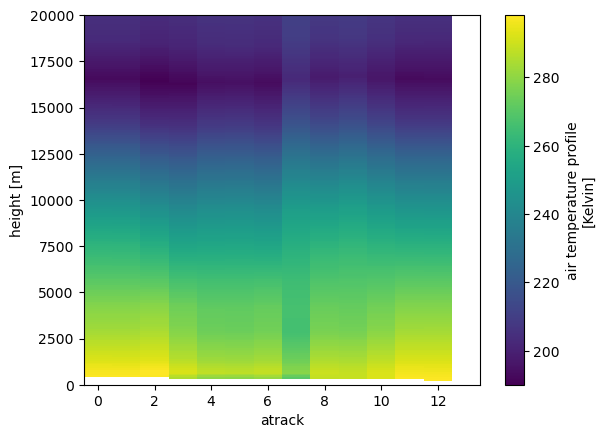

In [14]:
new_snpp_ds.air_temp[:,8].T.plot()

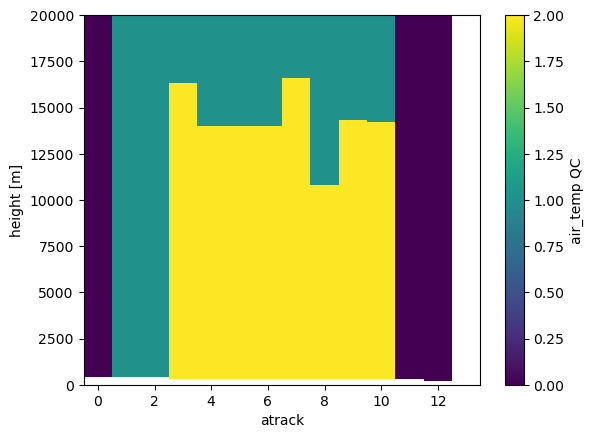

In [15]:
new_snpp_ds.air_temp_qc[:,8].T.plot()

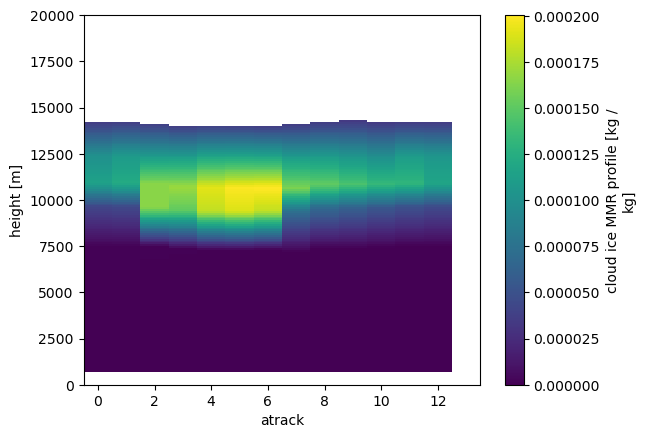

In [16]:
new_snpp_ds.h2o_ice_mmr[:,8].T.plot()

In [17]:
from metpy.calc import cape_cin, dewpoint_from_relative_humidity, parcel_profile, most_unstable_cape_cin, k_index
from metpy.units import units

In [22]:
def get_cape_cin_k_index(ds):
    p = ds.air_pres_h2o_stand.values * units.Pa
    T = ds.air_temp.sel(air_pres_stand=ds.air_pres_h2o_stand).values.reshape(-1, p.size) * units.K
    rh = ds.rel_hum.values.reshape(-1, p.size) * units.dimensionless
    Td = dewpoint_from_relative_humidity(T, rh).to("K")
    wh_nan = np.isnan(T)
    wh_good = p.size - wh_nan.sum(-1) > 2

    return np.array([
        [
            *[
                r.magnitude for r in most_unstable_cape_cin(
                    p[~wh_nan[i]], T[i][~wh_nan[i]], Td[i][~wh_nan[i]]
                )
            ], 
            k_index(p[~wh_nan[i]], T[i][~wh_nan[i]], Td[i][~wh_nan[i]]).magnitude
        ] \
        if check \
        else [np.nan, np.nan, np.nan] \
        for i, check in enumerate(p.size - wh_nan.sum(-1) > 2)
    ]).reshape(ds.surf_air_temp.shape+(3,))

In [23]:
def add_cape_cin_k_index_to_dataset(ds):
    met_results = get_cape_cin_k_index(ds)

    new_ds = ds[[]].copy()

    new_ds["CAPE"] = xr.DataArray(
        met_results[...,0], dims=["atrack", "xtrack"]
    )
    new_ds["CIN"] = xr.DataArray(
        met_results[...,1], dims=["atrack", "xtrack"]
    )
    new_ds["CAPE_CIN_qc"] = ds.air_temp_qc.sel(air_pres_stand=ds.air_pres_h2o_stand).where(
        np.isfinite(ds.air_temp.sel(air_pres_stand=ds.air_pres_h2o_stand))
    ).max("air_pres_h2o_stand")
    
    new_ds["k_index"] = xr.DataArray(
        met_results[...,2], dims=["atrack", "xtrack"]
    )
    new_ds["k_index_qc"] = ds.air_temp_qc.sel(air_pres_stand=ds.air_pres_h2o_stand).where(
        np.isfinite(ds.air_temp.sel(air_pres_stand=ds.air_pres_h2o_stand))
    ).max("air_pres_h2o_stand")
    
    return new_ds

In [24]:
add_cape_cin_k_index_to_dataset(dt.noaa_20.to_dataset())

/tmp/ipykernel_12360/561992284.py:5: UserWarning: Relative humidity >120%, ensure proper units.
  Td = dewpoint_from_relative_humidity(T, rh).to("K")
/tmp/ipykernel_12360/561992284.py:12: UserWarning: Interpolation point out of data bounds encountered
  r.magnitude for r in most_unstable_cape_cin(


<xarray.Dataset> Size: 6kB
Dimensions:      (atrack: 15, xtrack: 10)
Coordinates:
    lat          (atrack, xtrack) float32 600B 12.98 13.03 13.07 ... 11.13 11.16
    lon          (atrack, xtrack) float32 600B 80.26 80.0 79.74 ... 77.85 77.65
    subsat_lat   (atrack) float32 60B 13.99 13.84 13.68 ... 12.11 11.96 11.8
    subsat_lon   (atrack) float32 60B 74.06 74.02 73.98 ... 73.62 73.59 73.55
Dimensions without coordinates: atrack, xtrack
Data variables:
    CAPE         (atrack, xtrack) float64 1kB nan nan 83.73 ... nan nan
    CIN          (atrack, xtrack) float64 1kB nan nan -24.68 ... -71.82 nan nan
    CAPE_CIN_qc  (atrack, xtrack) float32 600B nan nan 2.0 nan ... 0.0 nan nan
    k_index      (atrack, xtrack) float64 1kB nan nan -24.68 ... -71.82 nan nan
    k_index_qc   (atrack, xtrack) float32 600B nan nan 2.0 nan ... 0.0 nan nan
Attributes: (12/82)
    geospatial_bounds:                 POLYGON ((86.04 14.29, 62.86 17.77, 58...
    product_name_version:              v03_21
    product_name_extension:            nc
    geospatial_lon_min:                58.613804
    creator_institution:               Goddard Space Flight Center - National...
    id:                                10.5067/69Y2R9BJAJS3
    ...                                ...
    AutomaticQualityFlag:              Passed
    instrument_vocabulary:             GCMD:GCMD Keywords
    date_created:                      2024-09-24T20:18:07.000Z
    license:                           Freely Distributed
    algorithm_version:                 V3.0.0,(20-Jan-2022)firo:1.0(30-JAN-2019)
    cdm_data_type:                     Swath

In [25]:
for var, data in add_cape_cin_k_index_to_dataset(dt.noaa_20.to_dataset()).data_vars.items():
    new_n20_ds[var] = data

/tmp/ipykernel_12360/561992284.py:5: UserWarning: Relative humidity >120%, ensure proper units.
  Td = dewpoint_from_relative_humidity(T, rh).to("K")
/tmp/ipykernel_12360/561992284.py:12: UserWarning: Interpolation point out of data bounds encountered
  r.magnitude for r in most_unstable_cape_cin(


In [26]:
for var, data in add_cape_cin_k_index_to_dataset(dt.snpp.to_dataset()).data_vars.items():
    new_snpp_ds[var] = data

/tmp/ipykernel_12360/561992284.py:5: UserWarning: Relative humidity >120%, ensure proper units.
  Td = dewpoint_from_relative_humidity(T, rh).to("K")
/tmp/ipykernel_12360/561992284.py:12: UserWarning: Interpolation point out of data bounds encountered
  r.magnitude for r in most_unstable_cape_cin(


In [27]:
dt["noaa_20"] = xr.DataTree(new_n20_ds)

In [28]:
dt["snpp"] = xr.DataTree(new_snpp_ds)

In [29]:
dt

<xarray.DataTree>
Group: /
├── Group: /AC__TC__2B
│       Dimensions:                           (along_track: 21, height: 200)
│       Coordinates:
│           time                              (along_track) datetime64[ns] 168B ...
│           latitude                          (along_track) float64 168B ...
│           longitude                         (along_track) float64 168B ...
│         * height                            (height) float64 2kB 1.995e+04 ... 50.0
│       Dimensions without coordinates: along_track
│       Data variables:
│           synergetic_target_classification  (along_track, height) float64 34kB ...
│           CPR_ATLID_status                  (along_track, height) float64 34kB ...
│           quality_status                    (along_track, height) float64 34kB ...
│       Attributes:
│           File_Name:         ECA_EXBA_AC__TC__2B_20240810T203032Z_20250904T221535Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         AC__TC__2B
│           File_Version:      0001
├── Group: /ACM_CAP_2B
│       Dimensions:                                     (along_track: 21, height: 200)
│       Coordinates:
│           time                                        (along_track) datetime64[ns] 168B ...
│           latitude                                    (along_track) float64 168B ...
│           longitude                                   (along_track) float64 168B ...
│         * height                                      (height) float64 2kB 1.995e+0...
│       Dimensions without coordinates: along_track
│       Data variables: (12/50)
│           tropopause_height                           (along_track) float32 84B ...
│           synergy_status                              (along_track) int8 21B ...
│           quality_status                              (along_track) int8 21B ...
│           ice_extinction                              (along_track, height) float32 17kB ...
│           ice_riming_index                            (along_track, height) float32 17kB ...
│           ice_riming_index_error                      (along_track, height) float32 17kB ...
│           ...                                          ...
│           aerosol_mass_content_error                  (along_track, height) float32 17kB ...
│           aerosol_extinction                          (along_track, height) float32 17kB ...
│           aerosol_extinction_error                    (along_track, height) float32 17kB ...
│           aerosol_optical_depth                       (along_track) float32 84B ...
│           aerosol_optical_depth_error                 (along_track) float32 84B ...
│           CPR_doppler_velocity                        (along_track, height) float32 17kB ...
│       Attributes:
│           File_Name:         ECA_EXBA_ACM_CAP_2B_20240810T203032Z_20250905T220717Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         ACM_CAP_2B
│           File_Version:      0001
├── Group: /ACM_RT__2B
│       Dimensions:                                      (along_track: 21,
│                                                         atmosphere_1d: 1,
│                                                         height_level: 249,
│                                                         height_layer: 248,
│                                                         atmosphere_3d: 1, height: 200)
│       Coordinates:
│           time                                         (along_track) datetime64[ns] 168B ...
│           latitude                                     (along_track) float32 84B ...
│           longitude                                    (along_track) float32 84B ...
│         * height                                       (height) float64 2kB 1.995e+...
│  

In [33]:
save_path = Path.home() / "my-public-bucket" / "orcestra" / "overpass_sounders"
save_path.mkdir(exist_ok=True)

In [34]:
dt.to_netcdf(save_path / overpass_files[0].name)

In [36]:
import warnings

In [38]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for i, f in enumerate(overpass_files):
        print(i, f.name)
        with xr.open_datatree(f) as dt:
            new_n20_ds = regrid_sounder_dataset(dt.noaa_20)
            for var, data in add_cape_cin_k_index_to_dataset(dt.noaa_20.to_dataset()).data_vars.items():
                new_n20_ds[var] = data
            dt["noaa_20"] = xr.DataTree(new_n20_ds)
    
            new_snpp_ds = regrid_sounder_dataset(dt.snpp)
            for var, data in add_cape_cin_k_index_to_dataset(dt.snpp.to_dataset()).data_vars.items():
                new_snpp_ds[var] = data
            dt["snpp"] = xr.DataTree(new_snpp_ds)
    
            dt.to_netcdf(save_path / f.name)

0 overpass_00000_01150A.nc
1 overpass_00001_01150D.nc
2 overpass_00002_01150D.nc
3 overpass_00003_01162B.nc
4 overpass_00004_01163E.nc
5 overpass_00005_01163E.nc
6 overpass_00006_01164D.nc
7 overpass_00007_01164D.nc
8 overpass_00008_01165E.nc
9 overpass_00009_01166A.nc
10 overpass_00010_01166E.nc
11 overpass_00011_01166E.nc
12 overpass_00012_01167E.nc
13 overpass_00013_01168E.nc
14 overpass_00014_01168E.nc
15 overpass_00015_01169E.nc
16 overpass_00016_01170A.nc
17 overpass_00017_01170A.nc
18 overpass_00018_01170E.nc
19 overpass_00019_01171A.nc
20 overpass_00020_01171A.nc
21 overpass_00021_01172A.nc
22 overpass_00022_01172B.nc
23 overpass_00023_01172A.nc
24 overpass_00024_01172D.nc
25 overpass_00025_01173D.nc
26 overpass_00026_01176E.nc
27 overpass_00027_01176H.nc
28 overpass_00028_01176E.nc
29 overpass_00029_01178E.nc
30 overpass_00030_01181A.nc
31 overpass_00031_01181A.nc
32 overpass_00032_01182A.nc
33 overpass_00033_01182A.nc
34 overpass_00034_01182A.nc
35 overpass_00035_01183A.nc
36